<a href="https://colab.research.google.com/github/Rupashree0806/rupa-codeboosters-2026/blob/main/Day-3/miniproject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
API_KEY='93535d167503396f377d6ea46d4f3d8a'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai', 'Delhi','Banglore','Chennai', 'Hydrabad','Kolkata','Pune','Jaipur']
print(f'API configured for{len(CITIES)} cities')
print(f'cities:{CITIES}')
print('\nIMPORTANT:''93535d167503396f377d6ea46d4f3d8a')


API configured for8 cities
cities:['Mumbai', 'Delhi', 'Banglore', 'Chennai', 'Hydrabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT:93535d167503396f377d6ea46d4f3d8a


In [ ]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)

    if response.status_code == 200:
      data = response.json()

      return {
          'city': city,
          'temperature': round(data['main']['temp'], 1),
          'feels_like': round(data['main']['feels_like'], 1),
          'humidity': data['main']['humidity'],
          'pressure': data['main']['pressure'],
          'wind_speed': data['wind']['speed'],
          'condition': data['weather'][0]['description'],
          'visibility': data['visibility']
      }
    else:
      print(f'ERROR {response.status_code} for {city}:{response.json().get("message")}')
      return None
  except requests.exceptions.RequestException as e:
    print(f'Request failed for {city}: {e}')
    return None


weather_records = []
print('Calling Weather API....')
for city in CITIES:
  print(f'Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}°C')
  else:
    print('Failed')

import pandas as pd
df_weather = pd.DataFrame(weather_records)
display(df_weather.head())

Calling Weather API....
Fetching: Mumbai...34.0°C
Fetching: Delhi...44.0°C
Fetching: Banglore...ERROR 404 for Banglore:city not found
Failed
Fetching: Chennai...35.9°C
Fetching: Hydrabad...ERROR 404 for Hydrabad:city not found
Failed
Fetching: Kolkata...32.0°C
Fetching: Pune...36.9°C
Fetching: Jaipur...42.6°C


,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,34.0,41.0,59,1009,6.17,haze,7000
1,Delhi,44.0,41.1,10,999,5.14,clear sky,7000
2,Chennai,35.9,42.9,54,1005,5.14,few clouds,6000
3,Kolkata,32.0,37.6,62,1001,4.12,haze,5000
4,Pune,36.9,36.8,27,1008,3.76,overcast clouds,10000


In [ ]:
weather_df=pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(f'\nShape:{weather_df.shape}')
print(f'Missing values:{weather_df.isnull().sum().sum()}')
print(f'\nData types:')
print(weather_df.dtypes)


Weather DataFrame created:
   city  temperature  feels_like  humidity  pressure  wind_speed       condition  visibility
 Mumbai         34.0        41.0        59      1009        6.17            haze        7000
  Delhi         44.0        41.1        10       999        5.14       clear sky        7000
Chennai         35.9        42.9        54      1005        5.14      few clouds        6000
Kolkata         32.0        37.6        62      1001        4.12            haze        5000
   Pune         36.9        36.8        27      1008        3.76 overcast clouds       10000
 Jaipur         42.6        41.3        15      1001        5.14            haze        5000

Shape:(6, 8)
Missing values:0

Data types:
city            object
temperature    float64
feels_like     float64
humidity         int64
pressure         int64
wind_speed     float64
condition       object
visibility       int64
dtype: object


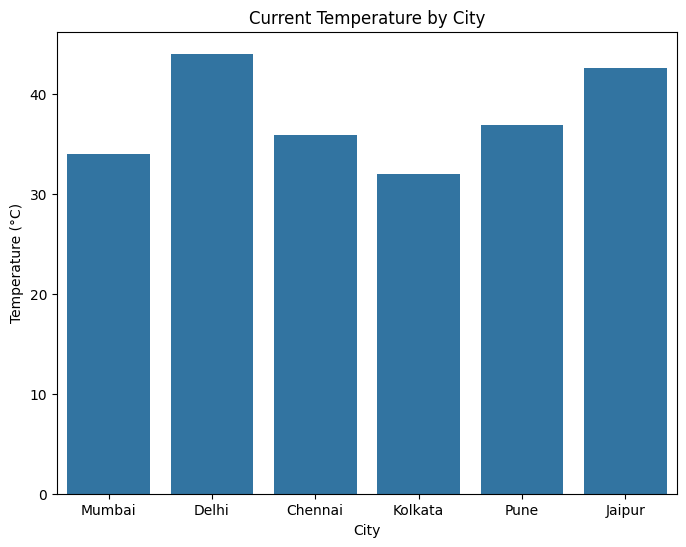

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.barplot(x='city', y='temperature', data=df_weather)
plt.title('Current Temperature by City')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.show()